In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from common.utils.parameters import (
    mcwf_dt_from_scales,
    omega_c,
    scaled_N_Gamma,
)
from parser.moments import MomentSeries, SimulationMetadata

%reload_ext autoreload
%autoreload 2

output_dir = repo_root / "output"

### Parameters

In [2]:
from solvers.mfe import compute_mfe_j_moments, solve_mfe
from parser.mfe import MFESolverParameters

from common.plotting import (
    plot_bloch_angles,
    plot_spin_components,
)

# common fixed
Gamma = 1; num_snapshots=100
# param
dN = 0
Ni = [10,10]


Omega_factor = 0.1
delta_factor = 0.02
omega_i = [0.7]



# Model and parameters
Omega0 = scaled_N_Gamma(Omega_factor, sum(Ni), Gamma)
delta0 = scaled_N_Gamma(delta_factor, sum(Ni), Gamma)
#delta0 = 1
# protocol durations
T1 = 10.0
T2 = 10.0
T3 = 10.0

simulation_metadata = SimulationMetadata(
    Ni=tuple(Ni),
    omega_i=tuple(omega_i),
    Gamma=Gamma,
    Omega0=Omega0,
    delta0=delta0,
    T1=T1,
    T2=T2,
    T3=T3,
)

print(f"Omega0 = {Omega0}")
print(f"delta0 = {delta0}")

Omega0 = 2.0
delta0 = 0.4


### Homogeneous MFE

In [3]:

# moment initialization
h_mfe_moments = MomentSeries(
    num_snapshots=num_snapshots,
    metadata=simulation_metadata,
)

# Define method parameters and solve using mean-field equations
h_mfe_parameters = MFESolverParameters(
    Ni=simulation_metadata.Ni,
    omega_i=simulation_metadata.omega_groups,
    Gamma=simulation_metadata.Gamma,
    phases=simulation_metadata.phases,
)
h_mfe_result = solve_mfe(
    h_mfe_parameters,
    t_eval=h_mfe_moments.t,
)

# compute moments
h_mfe_moments.J = compute_mfe_j_moments(h_mfe_result)


### Inhomogeneous MFE

In [4]:

# moment initialization
inh_mfe_moments = MomentSeries(
    num_snapshots=num_snapshots,
    metadata=simulation_metadata,
)

# Define method parameters and solve using mean-field equations
inh_mfe_parameters = MFESolverParameters(
    Ni=[sum(simulation_metadata.Ni)],
    omega_i=[1.0],
    Gamma=simulation_metadata.Gamma,
    phases=simulation_metadata.phases,
)
inh_mfe_result = solve_mfe(
    inh_mfe_parameters,
    t_eval=inh_mfe_moments.t,
)

# compute moments
inh_mfe_moments.J = compute_mfe_j_moments(inh_mfe_result)


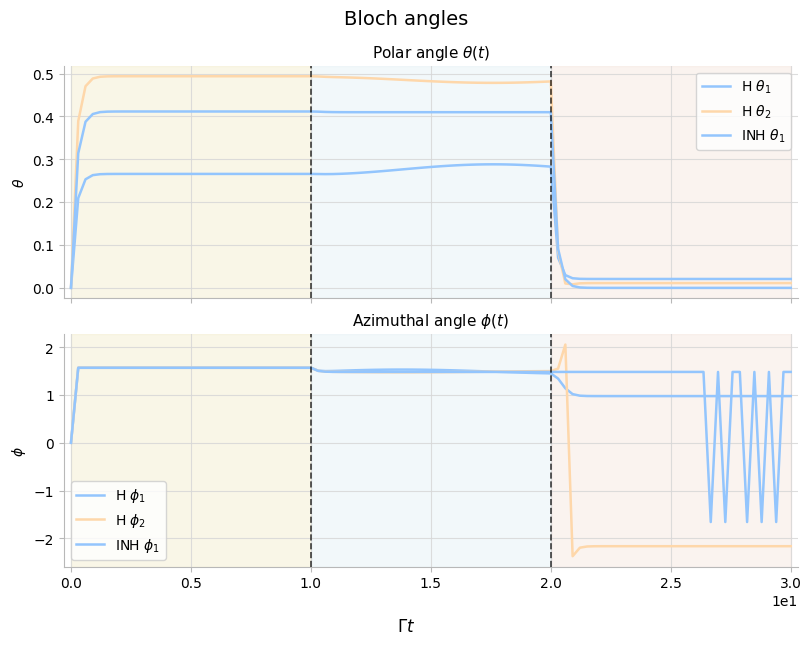

In [7]:

fig, axes = plot_bloch_angles(
    h_mfe_moments.J,
    phases=h_mfe_moments.metadata.phases,
    label=f"H",
    #colour_family_index=0,
    shade_index=0,
    linestyle="-",
)

fig, axes = plot_bloch_angles(
    inh_mfe_moments.J,
    phases=inh_mfe_moments.metadata.phases,
    label=f"INH",
    #colour_family_index=0,
    shade_index=0,
    linestyle="-",
    axes=axes,
)

# fig, axes_spins = plot_spin_components(
#     mfe_moments.J,
#     normalized=True,
#     phases=mfe_moments.metadata.phases,
#     label=f"N = {2*NJi}",
#     colour_index=i,
#     linestyle="-",
#     axes=axes_spins
# )



### Mean-field Equations

### Plotting

In [ ]:
from solvers.mfe import compute_mfe_j_moments, solve_mfe
from parser.mfe import MFESolverParameters



# moment initialization
mfe_moments = MomentSeries(
    num_snapshots=num_snapshots,
    metadata=simulation_metadata,
)

# Define method parameters and solve using mean-field equations
mfe_parameters = MFESolverParameters(
    Ni=simulation_metadata.Ni,
    omega_i=simulation_metadata.omega_groups,
    Gamma=simulation_metadata.Gamma,
    phases=simulation_metadata.phases,
)
mfe_result = solve_mfe(
    mfe_parameters,
    t_eval=mfe_moments.t,
)

# compute moments
mfe_moments.J = compute_mfe_j_moments(mfe_result)